## Connecting to MySQL

- import mysql_connector in VS code terminal: 
- python -m pip install mysql_connector

In [ ]:
import mysql.connector

def create_connection():
    connection=mysql.connector.connect(
        host="localhost",
        user="root",
        password="####",
        database="STORE_ANALYSIS"
    )
    return connection

# Reading a query from MySQL

- importing pandas and matplotlib
- checking connection 

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
conn=create_connection()
query="""
SELECT AVG(Store_Sales) AS Average_Store_Sales
FROM stores;
"""
df=pd.read_sql_query(query,conn)
print(df)

   Average_Store_Sales
0           59351.3058


C:\Users\user\AppData\Local\Temp\ipykernel_21832\2073548357.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,conn)


# Bar Chart of Top 10 stores

   Store_ID  Store_Sales
0       650       116320
1       869       105150
2       433       102920
3       409       102310
4       759       101820
5       558       101780
6       867       100900
7       167        99570
8       693        99480
9       872        98260


C:\Users\user\AppData\Local\Temp\ipykernel_21832\3736351112.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,conn)


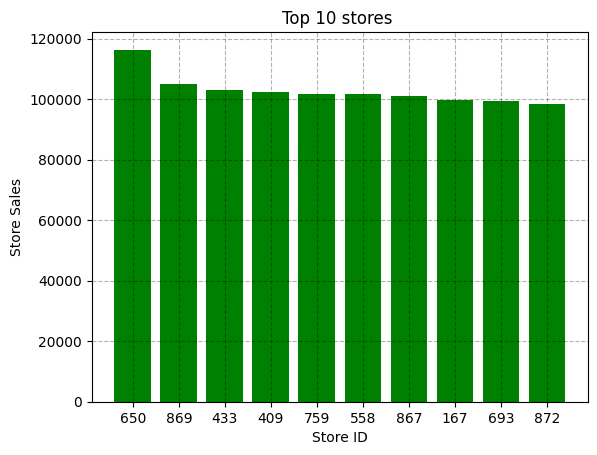

In [82]:
query="""
SELECT Store_ID, Store_Sales 
FROM stores
ORDER BY Store_Sales DESC
LIMIT 10;
"""
df=pd.read_sql_query(query,conn)
print(df)
plt.bar(df["Store_ID"].astype(str),df["Store_Sales"],color="green")
plt.title("Top 10 stores ")
plt.xlabel("Store ID")
plt.ylabel("Store Sales")
plt.grid(alpha=0.3,color="black",linestyle="--")
plt.show()


# Plotting for top 10 stores with most available items

C:\Users\user\AppData\Local\Temp\ipykernel_21832\1465773130.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,conn)


   Store_ID  Items_Available
0       467             2667
1       541             2647
2        92             2617
3       399             2493
4       850             2492
5       164             2474
6       551             2465
7       470             2436
8       799             2420
9       650             2414


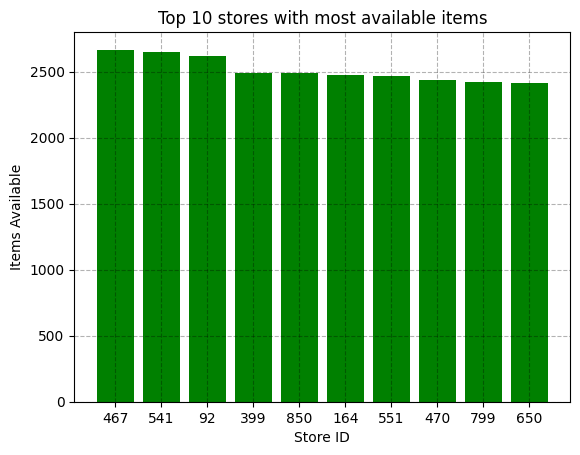

In [83]:
query="""
SELECT Store_ID, Items_Available
FROM stores
ORDER BY Items_Available DESC
LIMIT 10;
"""
df=pd.read_sql_query(query,conn)
print(df)
plt.bar(df["Store_ID"].astype(str),df["Items_Available"],color="green",alpha=1)
plt.title("Top 10 stores with most available items")
plt.xlabel("Store ID")
plt.ylabel("Items Available")
plt.grid(alpha=0.3,color="black",linestyle="--")
plt.show() 

# Total high sales level stores vs Low sales level stores

C:\Users\user\AppData\Local\Temp\ipykernel_21832\1434185077.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,conn)


  Sales_Level  Total_Stores
0         Low           475
1        High           421


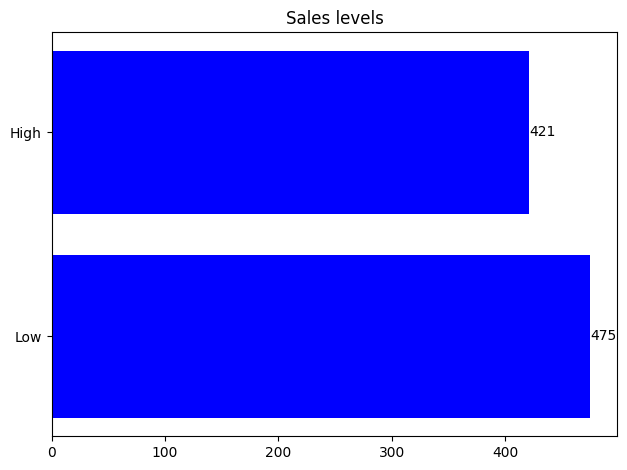

In [84]:
query="""
SELECT Sales_Level, COUNT(Store_ID) AS Total_Stores
FROM stores
GROUP BY Sales_Level
ORDER BY Total_Stores DESC;
"""
df=pd.read_sql_query(query,conn)
print(df)
plt.barh(df["Sales_Level"],df["Total_Stores"],color="blue")
plt.title("Sales levels")
for i in range(len(df["Sales_Level"])):
    plt.text(df["Total_Stores"][i], i, df["Total_Stores"][i], va="center")
plt.tight_layout()
plt.show() 

# Correlation Matrix

C:\Users\user\AppData\Local\Temp\ipykernel_21832\675308869.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


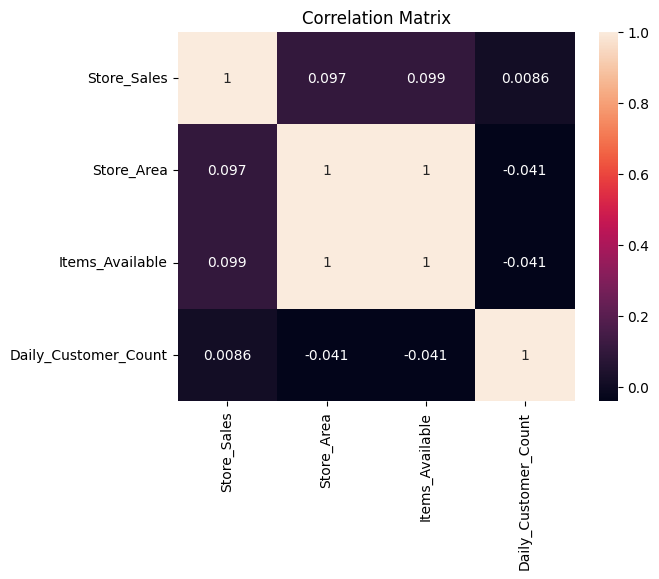

In [85]:
import seaborn as sns
query = """
SELECT 
    Store_Sales,
    Store_Area,
    Items_Available,
    Daily_Customer_Count
FROM stores;
"""

df = pd.read_sql_query(query, conn)

sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Insights from correlation matrix
- Usually sales have strong positive correlation with area and daily customer count. But in this dataset store sales doesnt have any strong positive relation with store area, items available and Daily Customer Count. Maybe It can depend on any other attribute like location or customer flow.
- its expected that larger store will have larger number of customers, but store area have ~0 correlation with daily customer count. As daily count also counts regular customers and small area stores might have more regular customers. This suggests other external factors (not present in dataset) may influence sales.
- High stock will bring high number of customers, it's not true for all. We can see Items Available have ~0 correlation with Daily Customer Count. It means sometimes owners high stock can be their own burden as market trends and customer choices changes fast.

## RegPlots

# REGPLOT FOR AREA-SALES

C:\Users\user\AppData\Local\Temp\ipykernel_21832\1310327436.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,conn)


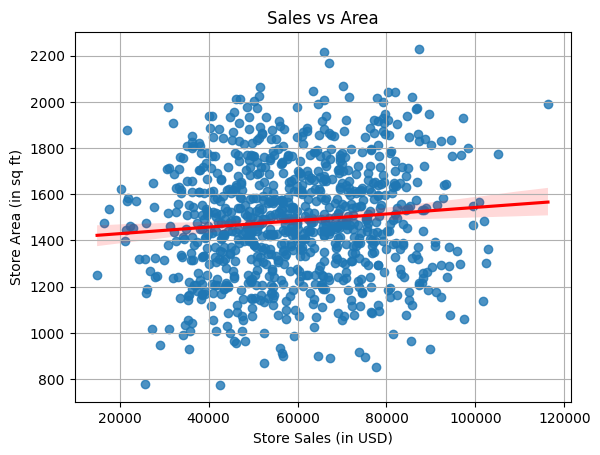

In [86]:
query="""
SELECT*
FROM stores;
"""
df=pd.read_sql_query(query,conn)
sns.regplot(x=df["Store_Sales"],y=df["Store_Area"],line_kws={'color': 'red'})
plt.xlabel("Store Sales (in USD)")
plt.ylabel("Store Area (in sq ft)")
plt.grid()
plt.title("Sales vs Area")
plt.show()

* Insight:
Big stores will have big sales, its what many thinks. But in this plot we can see, small stores also have high sales and many big stores are actually lower in sales than some small stores sales. 

# regplot for area and daily customer count

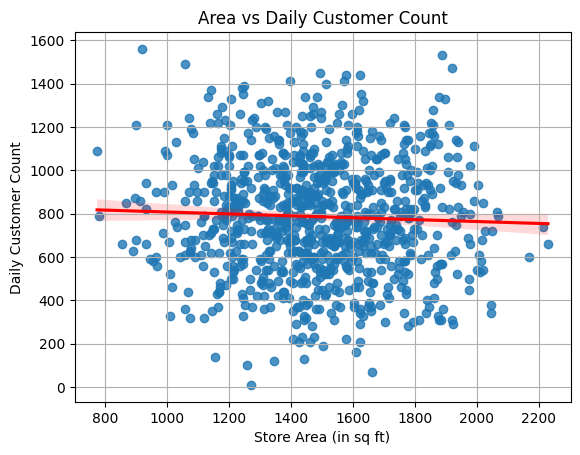

In [87]:
sns.regplot(x=df["Store_Area"],y=df["Daily_Customer_Count"],line_kws={'color': 'red'})
plt.xlabel("Store Area (in sq ft)")
plt.ylabel("Daily Customer Count")
plt.grid()
plt.title("Area vs Daily Customer Count")
plt.show()

larger store area doesnt mean it will have larger number of daily customers. Its seems that many stores with larger area actually have less daily customer than many small area stores. 

# Histogram for sales distribution

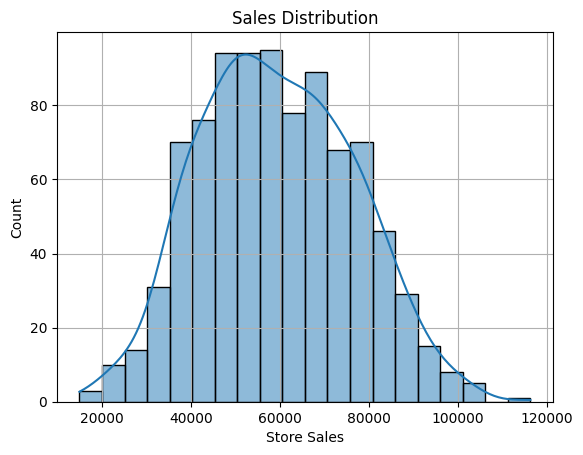

In [88]:
sns.histplot(df["Store_Sales"], bins=20, kde=True)
plt.xlabel("Store Sales")
plt.grid()
plt.title("Sales Distribution")
plt.show()

# Histogram for Available Items Distribution

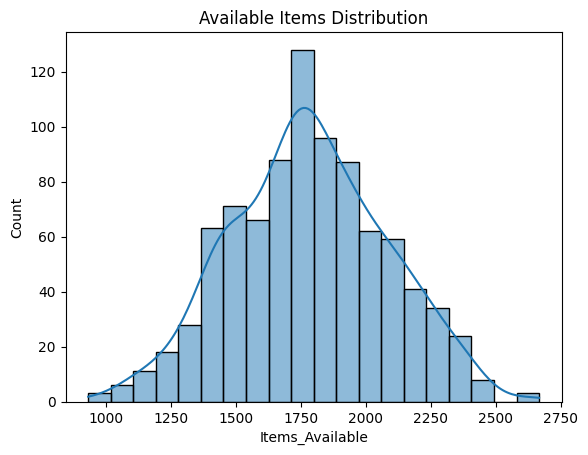

In [89]:
sns.histplot(df["Items_Available"], bins=20, kde=True)
plt.xlabel("Items_Available")
plt.title("Available Items Distribution")
plt.show()

# Boxplot for outliers in store sales

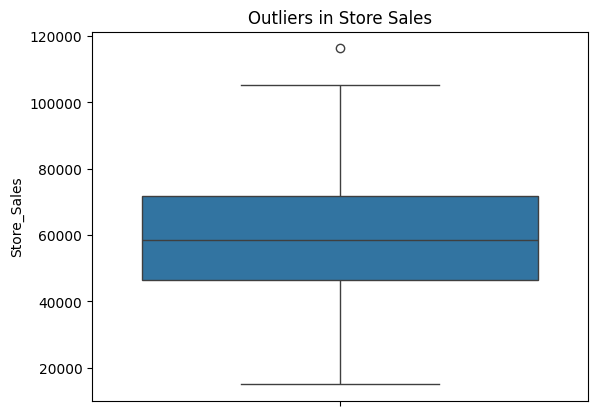

In [90]:
sns.boxplot(y=df["Store_Sales"])
plt.title("Outliers in Store Sales")
plt.show()

* insights: 
1. The median store sales sit around 60,000, with the majority of stores falling between approximately 45,000 and 75,000.
2. A few outliers exist above 80,000, indicating some stores significantly outperform others.

# FINAL INSIGHTS

1. Store Area has little to no impact on sales.
2. Items Available does not strongly influence customer count.
3. Sales are likely influenced by external factors such as location, marketing, or customer experience.
4. Most stores operate within a similar sales range (45k–75k), with few outliers.